In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
import os

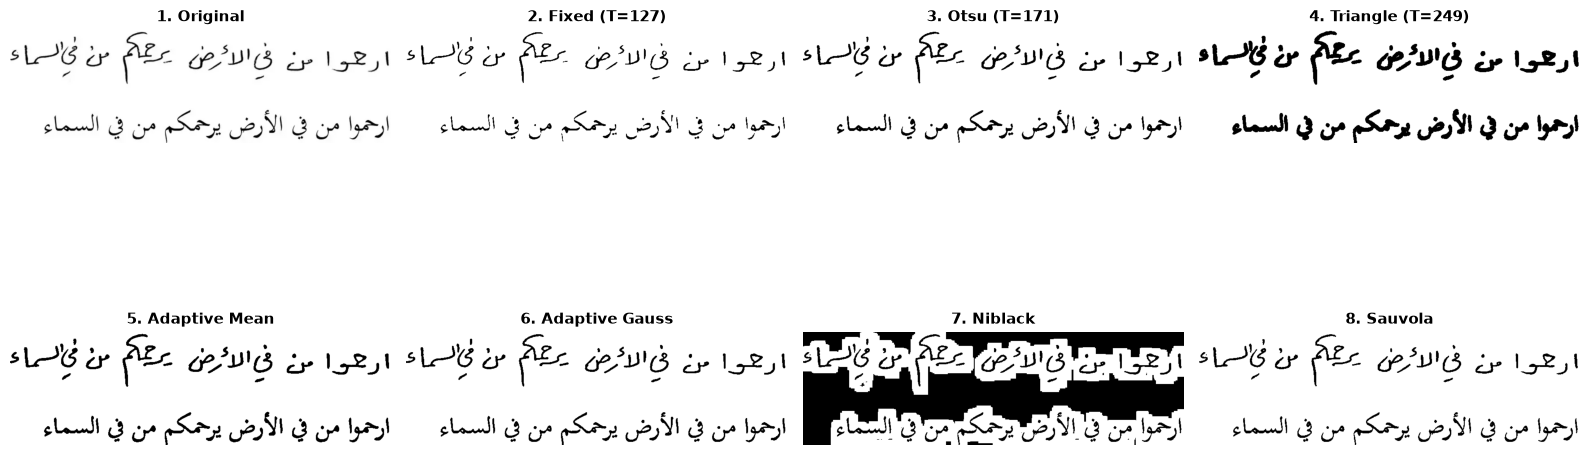

In [6]:

# ==========================================
# 1. LOAD IMAGE
# ==========================================
image_path = r"C:\Users\PC-LAB1\img_processing_lab\images\handwrittenArabic.webp"

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'")
else:
    # Read as grayscale
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray_img is None:
        print("Error: Could not read image.")
    else:
        # Pre-blur to reduce high-frequency noise
        blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)

        # ==========================================
        # 2. GLOBAL THRESHOLDING (OpenCV)
        # ==========================================
        # 1. Fixed Global
        _, thresh_fixed = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

        # 2. Otsu
        otsu_val, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 3. Triangle
        tri_val, thresh_triangle = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

        # ==========================================
        # 3. ADAPTIVE LOCAL THRESHOLDING (OpenCV)
        # ==========================================
        # 4. Adaptive Mean
        thresh_adapt_mean = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # 5. Adaptive Gaussian
        thresh_adapt_gauss = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # ==========================================
        # 4. STATISTICAL LOCAL THRESHOLDING (scikit-image)
        # ==========================================
        window_size = 25

        # 6. Niblack Thresholding
        thresh_nib_val = threshold_niblack(gray_img, window_size=window_size, k=0.2)
        thresh_niblack = (gray_img > thresh_nib_val).astype('uint8') * 255

        # 7. Sauvola Thresholding
        thresh_sau_val = threshold_sauvola(gray_img, window_size=window_size, k=0.2)
        thresh_sauvola = (gray_img > thresh_sau_val).astype('uint8') * 255

        # ==========================================
        # 5. PLOT ALL 7 METHODS
        # ==========================================
        titles = [
            '1. Original',
            '2. Fixed (T=127)',
            f'3. Otsu (T={int(otsu_val)})',
            f'4. Triangle (T={int(tri_val)})',
            '5. Adaptive Mean',
            '6. Adaptive Gauss',
            '7. Niblack',
            '8. Sauvola'
        ]

        images = [
            gray_img,
            thresh_fixed,
            thresh_otsu,
            thresh_triangle,
            thresh_adapt_mean,
            thresh_adapt_gauss,
            thresh_niblack,
            thresh_sauvola
        ]

        plt.figure(figsize=(16, 8))

        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i], fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

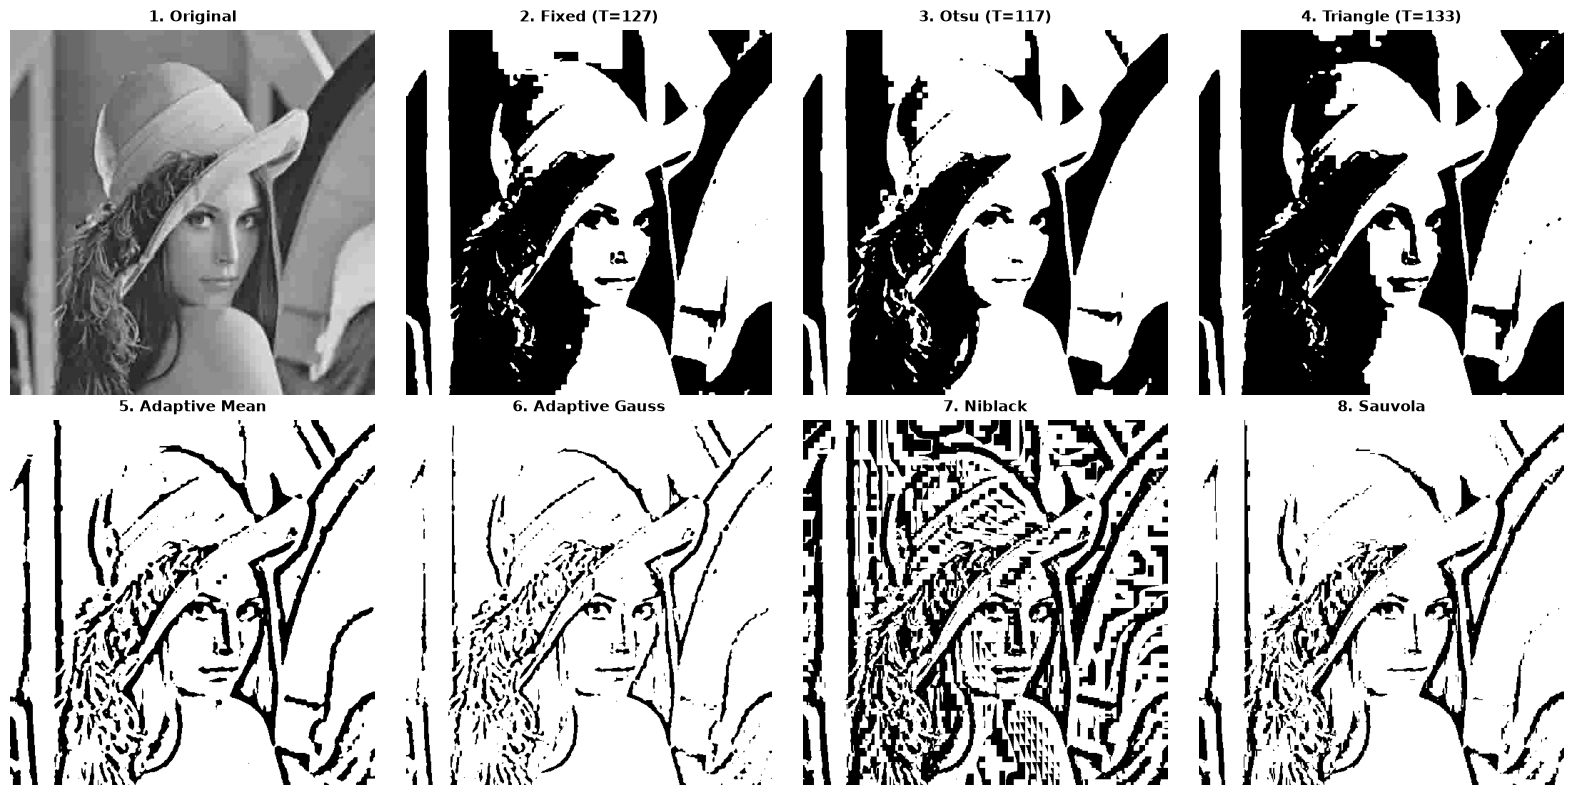

In [7]:
import cv2
import matplotlib.pyplot as plt
import os
from skimage.filters import threshold_niblack, threshold_sauvola

# ==========================================
# 1. LOAD IMAGE
# ==========================================
image_path = r"C:\Users\PC-LAB1\img_processing_lab\images\lena5.jpg"

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'")
else:
    # Read as grayscale
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray_img is None:
        print("Error: Could not read image.")
    else:
        # Pre-blur to reduce high-frequency noise
        blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)

        # ==========================================
        # 2. GLOBAL THRESHOLDING (OpenCV)
        # ==========================================
        # 1. Fixed Global
        _, thresh_fixed = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

        # 2. Otsu
        otsu_val, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 3. Triangle
        tri_val, thresh_triangle = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

        # ==========================================
        # 3. ADAPTIVE LOCAL THRESHOLDING (OpenCV)
        # ==========================================
        # 4. Adaptive Mean
        thresh_adapt_mean = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # 5. Adaptive Gaussian
        thresh_adapt_gauss = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # ==========================================
        # 4. STATISTICAL LOCAL THRESHOLDING (scikit-image)
        # ==========================================
        window_size = 25

        # 6. Niblack Thresholding
        thresh_nib_val = threshold_niblack(gray_img, window_size=window_size, k=0.2)
        thresh_niblack = (gray_img > thresh_nib_val).astype('uint8') * 255

        # 7. Sauvola Thresholding
        thresh_sau_val = threshold_sauvola(gray_img, window_size=window_size, k=0.2)
        thresh_sauvola = (gray_img > thresh_sau_val).astype('uint8') * 255

        # ==========================================
        # 5. PLOT ALL 7 METHODS
        # ==========================================
        titles = [
            '1. Original',
            '2. Fixed (T=127)',
            f'3. Otsu (T={int(otsu_val)})',
            f'4. Triangle (T={int(tri_val)})',
            '5. Adaptive Mean',
            '6. Adaptive Gauss',
            '7. Niblack',
            '8. Sauvola'
        ]

        images = [
            gray_img,
            thresh_fixed,
            thresh_otsu,
            thresh_triangle,
            thresh_adapt_mean,
            thresh_adapt_gauss,
            thresh_niblack,
            thresh_sauvola
        ]

        plt.figure(figsize=(16, 8))

        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i], fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

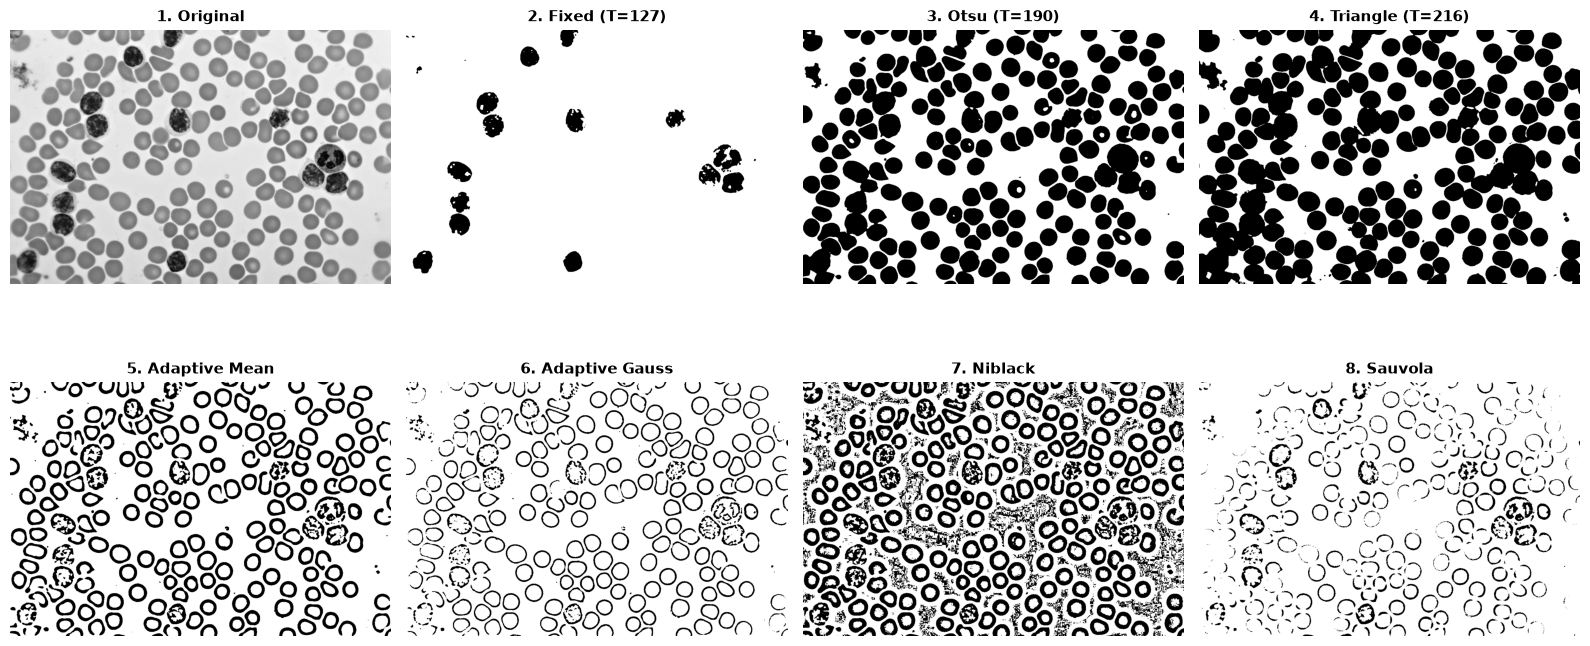

In [8]:
import cv2
import matplotlib.pyplot as plt
import os
from skimage.filters import threshold_niblack, threshold_sauvola

# ==========================================
# 1. LOAD IMAGE
# ==========================================
image_path = r"C:\Users\PC-LAB1\img_processing_lab\images\bloodcells.jpeg"

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'")
else:
    # Read as grayscale
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray_img is None:
        print("Error: Could not read image.")
    else:
        # Pre-blur to reduce high-frequency noise
        blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)

        # ==========================================
        # 2. GLOBAL THRESHOLDING (OpenCV)
        # ==========================================
        # 1. Fixed Global
        _, thresh_fixed = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

        # 2. Otsu
        otsu_val, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 3. Triangle
        tri_val, thresh_triangle = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

        # ==========================================
        # 3. ADAPTIVE LOCAL THRESHOLDING (OpenCV)
        # ==========================================
        # 4. Adaptive Mean
        thresh_adapt_mean = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # 5. Adaptive Gaussian
        thresh_adapt_gauss = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # ==========================================
        # 4. STATISTICAL LOCAL THRESHOLDING (scikit-image)
        # ==========================================
        window_size = 25

        # 6. Niblack Thresholding
        thresh_nib_val = threshold_niblack(gray_img, window_size=window_size, k=0.2)
        thresh_niblack = (gray_img > thresh_nib_val).astype('uint8') * 255

        # 7. Sauvola Thresholding
        thresh_sau_val = threshold_sauvola(gray_img, window_size=window_size, k=0.2)
        thresh_sauvola = (gray_img > thresh_sau_val).astype('uint8') * 255

        # ==========================================
        # 5. PLOT ALL 7 METHODS
        # ==========================================
        titles = [
            '1. Original',
            '2. Fixed (T=127)',
            f'3. Otsu (T={int(otsu_val)})',
            f'4. Triangle (T={int(tri_val)})',
            '5. Adaptive Mean',
            '6. Adaptive Gauss',
            '7. Niblack',
            '8. Sauvola'
        ]

        images = [
            gray_img,
            thresh_fixed,
            thresh_otsu,
            thresh_triangle,
            thresh_adapt_mean,
            thresh_adapt_gauss,
            thresh_niblack,
            thresh_sauvola
        ]

        plt.figure(figsize=(16, 8))

        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i], fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()

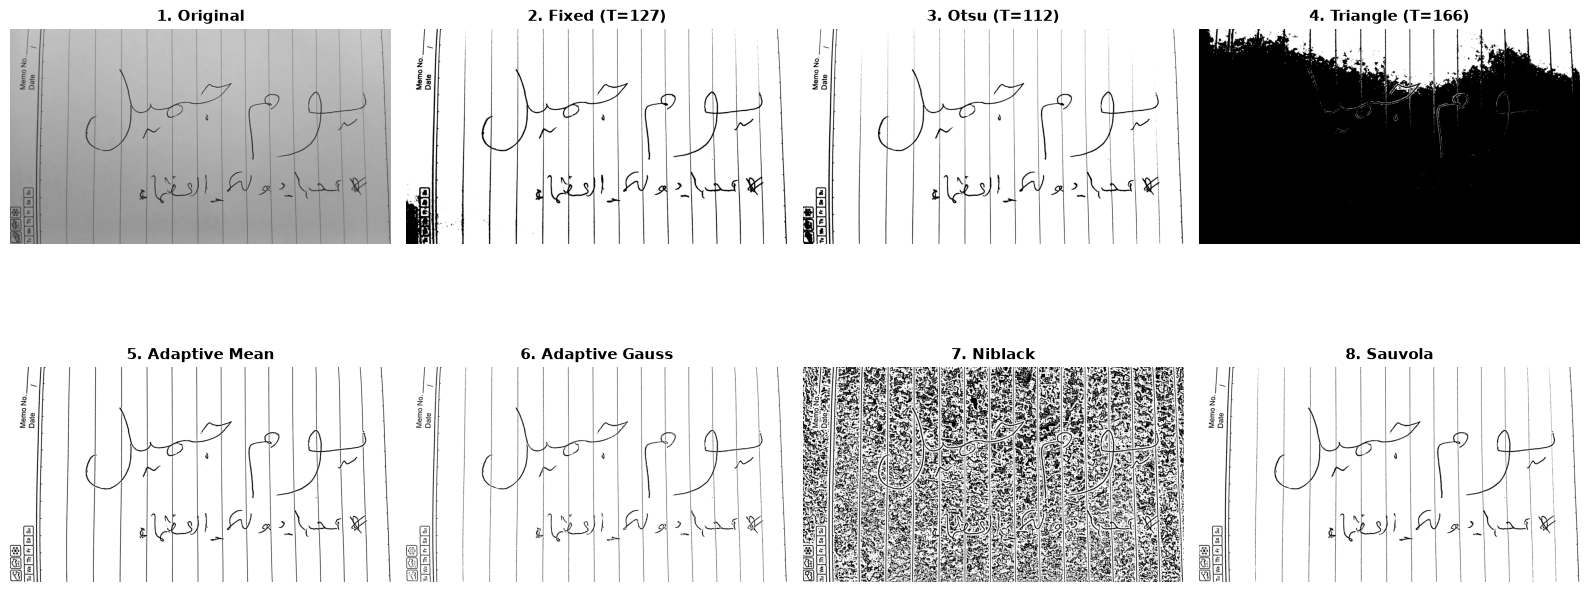

In [15]:

# ==========================================
# 1. LOAD IMAGE
# ==========================================
image_path = r"C:\Users\PC-LAB1\img_processing_lab\images\mywriting.jpg"

if not os.path.exists(image_path):
    print(f"Error: File not found at '{image_path}'")
else:
    # Read as grayscale
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if gray_img is None:
        print("Error: Could not read image.")
    else:
        # Pre-blur to reduce high-frequency noise
        blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)

        # ==========================================
        # 2. GLOBAL THRESHOLDING (OpenCV)
        # ==========================================
        # 1. Fixed Global
        _, thresh_fixed = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

        # 2. Otsu
        otsu_val, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # 3. Triangle
        tri_val, thresh_triangle = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)

        # ==========================================
        # 3. ADAPTIVE LOCAL THRESHOLDING (OpenCV)
        # ==========================================
        # 4. Adaptive Mean
        thresh_adapt_mean = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # 5. Adaptive Gaussian
        thresh_adapt_gauss = cv2.adaptiveThreshold(
            blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, blockSize=25, C=10
        )

        # ==========================================
        # 4. STATISTICAL LOCAL THRESHOLDING (scikit-image)
        # ==========================================
        window_size = 25

        # 6. Niblack Thresholding
        thresh_nib_val = threshold_niblack(gray_img, window_size=window_size, k=0.2)
        thresh_niblack = (gray_img > thresh_nib_val).astype('uint8') * 255

        # 7. Sauvola Thresholding
        thresh_sau_val = threshold_sauvola(gray_img, window_size=window_size, k=0.2)
        thresh_sauvola = (gray_img > thresh_sau_val).astype('uint8') * 255

        # ==========================================
        # 5. PLOT ALL 7 METHODS
        # ==========================================
        titles = [
            '1. Original',
            '2. Fixed (T=127)',
            f'3. Otsu (T={int(otsu_val)})',
            f'4. Triangle (T={int(tri_val)})',
            '5. Adaptive Mean',
            '6. Adaptive Gauss',
            '7. Niblack',
            '8. Sauvola'
        ]

        images = [
            gray_img,
            thresh_fixed,
            thresh_otsu,
            thresh_triangle,
            thresh_adapt_mean,
            thresh_adapt_gauss,
            thresh_niblack,
            thresh_sauvola
        ]

        plt.figure(figsize=(16, 8))

        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.title(titles[i], fontsize=11, fontweight='bold')
            plt.axis('off')

        plt.tight_layout()
        plt.show()